# EDA, Part 2: Visual Exploration

Follow-up to `01-eda.ipynb` (table-by-table profiling). This notebook focuses on plots that
should inform feature engineering and model choices:

- does seed actually predict tournament outcomes, and how noisy is that relationship (upsets)?
- how different is score-margin behavior in the regular season vs. the tournament (relevant
  to the Section 3 training-scope question — is the tournament a different distribution)?
- data coverage over time across files, visualized (COVID 2020 gap, detailed-stats start years)
- does the Massey Ordinal power ranking differential actually track tournament outcomes?


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("../data")

m_seeds = pd.read_csv(DATA_DIR / "MNCAATourneySeeds.csv")
w_seeds = pd.read_csv(DATA_DIR / "WNCAATourneySeeds.csv")
m_tourney = pd.read_csv(DATA_DIR / "MNCAATourneyCompactResults.csv")
w_tourney = pd.read_csv(DATA_DIR / "WNCAATourneyCompactResults.csv")
m_reg = pd.read_csv(DATA_DIR / "MRegularSeasonCompactResults.csv")
w_reg = pd.read_csv(DATA_DIR / "WRegularSeasonCompactResults.csv")
m_reg_detail = pd.read_csv(DATA_DIR / "MRegularSeasonDetailedResults.csv")
w_reg_detail = pd.read_csv(DATA_DIR / "WRegularSeasonDetailedResults.csv")
ordinals = pd.read_csv(DATA_DIR / "MMasseyOrdinals.csv")
m_teams = pd.read_csv(DATA_DIR / "MTeams.csv")

def seed_num(s):
    return int("".join(ch for ch in s if ch.isdigit()))

m_seeds["SeedNum"] = m_seeds["Seed"].apply(seed_num)
w_seeds["SeedNum"] = w_seeds["Seed"].apply(seed_num)
print("loaded all tables")


loaded all tables


## 1. Does seed actually predict who wins?

For every historical tournament game, look up both teams' seeds and record whether the better (lower-numbered) seed won. Aggregate by the seed match-up gap.

men's: better (lower) seed won 71.6% of non-tied-seed games (2488 games)
women's: better (lower) seed won 78.3% of non-tied-seed games (1672 games)


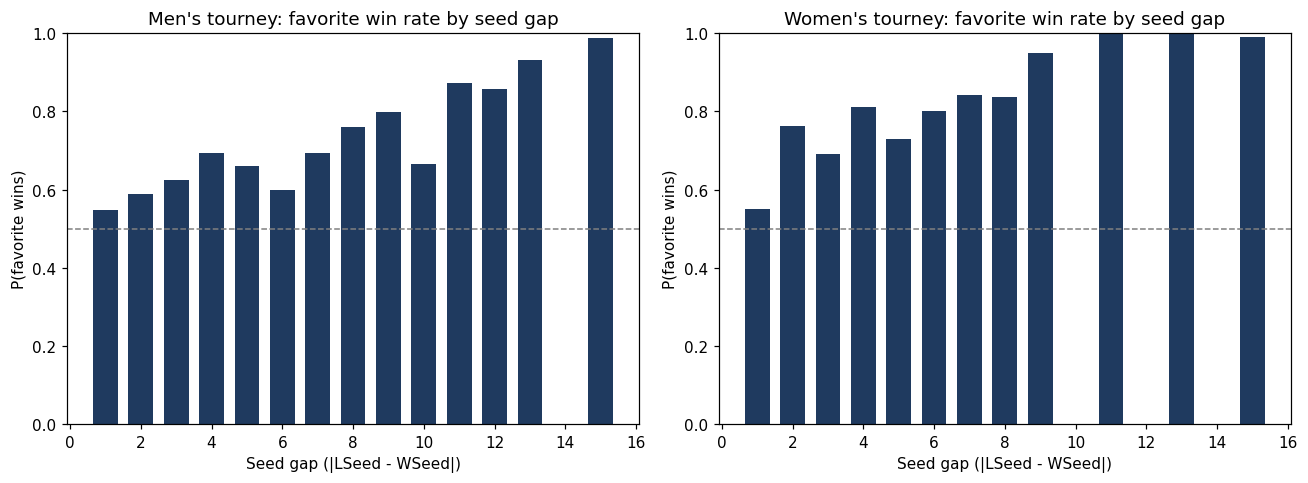

In [2]:
def seed_win_analysis(tourney, seeds):
    s = seeds.set_index(["Season", "TeamID"])["SeedNum"]
    df = tourney.copy()
    df["WSeed"] = df.apply(lambda r: s.get((r["Season"], r["WTeamID"]), np.nan), axis=1)
    df["LSeed"] = df.apply(lambda r: s.get((r["Season"], r["LTeamID"]), np.nan), axis=1)
    df = df.dropna(subset=["WSeed", "LSeed"])
    # exclude equal-seed matchups: WSeed <= LSeed would be trivially true on a tie and skew the
    # gap=0 bucket to a meaningless 100% - "better seed" isn't defined when seeds are equal
    df = df[df["WSeed"] != df["LSeed"]].copy()
    df["BetterSeedWon"] = df["WSeed"] < df["LSeed"]
    df["SeedGap"] = (df["LSeed"] - df["WSeed"]).abs()
    return df

m_analysis = seed_win_analysis(m_tourney, m_seeds)
w_analysis = seed_win_analysis(w_tourney, w_seeds)

print(f"men's: better (lower) seed won {m_analysis['BetterSeedWon'].mean():.1%} of non-tied-seed games ({len(m_analysis)} games)")
print(f"women's: better (lower) seed won {w_analysis['BetterSeedWon'].mean():.1%} of non-tied-seed games ({len(w_analysis)} games)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, df, label in [(axes[0], m_analysis, "Men's"), (axes[1], w_analysis, "Women's")]:
    rate = df.groupby("SeedGap")["BetterSeedWon"].agg(["mean", "count"])
    rate = rate[rate["count"] >= 5]
    ax.bar(rate.index, rate["mean"], color="#1f3a5f", width=0.7)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Seed gap (|LSeed - WSeed|)")
    ax.set_ylabel("P(favorite wins)")
    ax.set_title(f"{label} tourney: favorite win rate by seed gap")
    ax.set_ylim(0, 1)
fig.tight_layout()
plt.show()


## 2. Regular season vs. tournament score margins

If tournament games are systematically different from regular season games (closer, higher stakes, no home court), the margin distributions should look different — relevant to the training-scope question of whether regular-season games are a safe stand-in for tournament games.

men's regular season median margin: 10, mean: 12.1
men's tournament median margin:      10, mean: 11.8


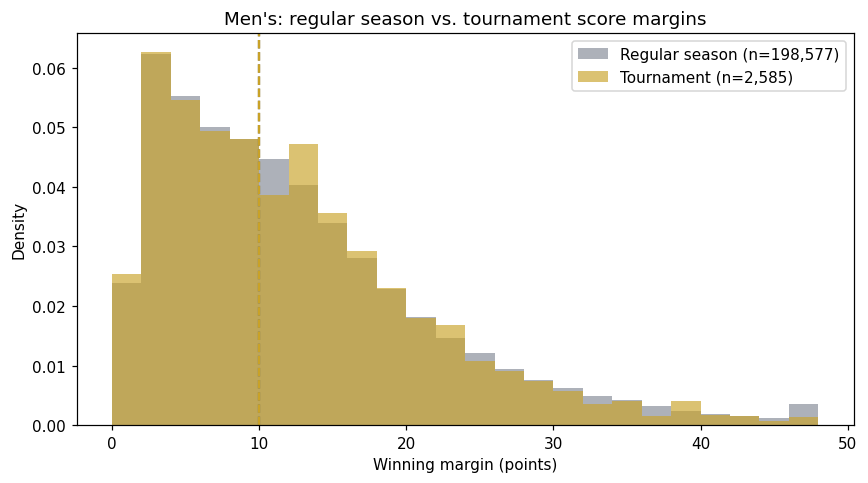

In [3]:
m_reg_margin = (m_reg["WScore"] - m_reg["LScore"])
m_tourney_margin = (m_tourney["WScore"] - m_tourney["LScore"])

fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.arange(0, 50, 2)
ax.hist(m_reg_margin.clip(upper=48), bins=bins, alpha=0.55, density=True, label=f"Regular season (n={len(m_reg_margin):,})", color="#6b7280")
ax.hist(m_tourney_margin.clip(upper=48), bins=bins, alpha=0.65, density=True, label=f"Tournament (n={len(m_tourney_margin):,})", color="#c9a227")
ax.axvline(m_reg_margin.median(), color="#6b7280", linestyle="--", linewidth=1.5)
ax.axvline(m_tourney_margin.median(), color="#c9a227", linestyle="--", linewidth=1.5)
ax.set_xlabel("Winning margin (points)")
ax.set_ylabel("Density")
ax.set_title("Men's: regular season vs. tournament score margins")
ax.legend()
fig.tight_layout()
plt.show()

print(f"men's regular season median margin: {m_reg_margin.median():.0f}, mean: {m_reg_margin.mean():.1f}")
print(f"men's tournament median margin:      {m_tourney_margin.median():.0f}, mean: {m_tourney_margin.mean():.1f}")


## 3. Data coverage over time

Visual version of the season-range findings from notebook 1 — makes the 2020 COVID gap and the detailed-stats start years easy to see at a glance.

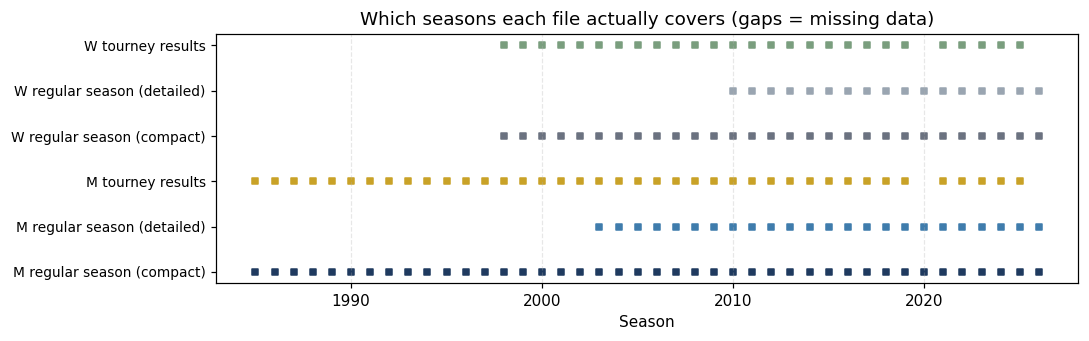

In [4]:
fig, ax = plt.subplots(figsize=(10, 3.2))
series = [
    ("M regular season (compact)", m_reg["Season"], "#1f3a5f"),
    ("M regular season (detailed)", m_reg_detail["Season"], "#3f7cac"),
    ("M tourney results", m_tourney["Season"], "#c9a227"),
    ("W regular season (compact)", w_reg["Season"], "#6b7280"),
    ("W regular season (detailed)", w_reg_detail["Season"], "#9aa5b1"),
    ("W tourney results", w_tourney["Season"], "#7a9e7e"),
]
for i, (label, seasons, color) in enumerate(series):
    yrs = sorted(seasons.unique())
    ax.scatter(yrs, [i] * len(yrs), color=color, marker="s", s=14)
ax.set_yticks(range(len(series)))
ax.set_yticklabels([s[0] for s in series], fontsize=9)
ax.set_xlabel("Season")
ax.set_title("Which seasons each file actually covers (gaps = missing data)")
ax.grid(axis="x", linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()


## 4. Massey Ordinal rank differential vs. tournament outcome (men's only)

For each men's tournament game, pull both teams' power-ranking as of the last ranking day before that season's tournament, and see whether the ranking gap actually tracks who won.

better-ranked team won 71.0% of 1449 games with ranking data


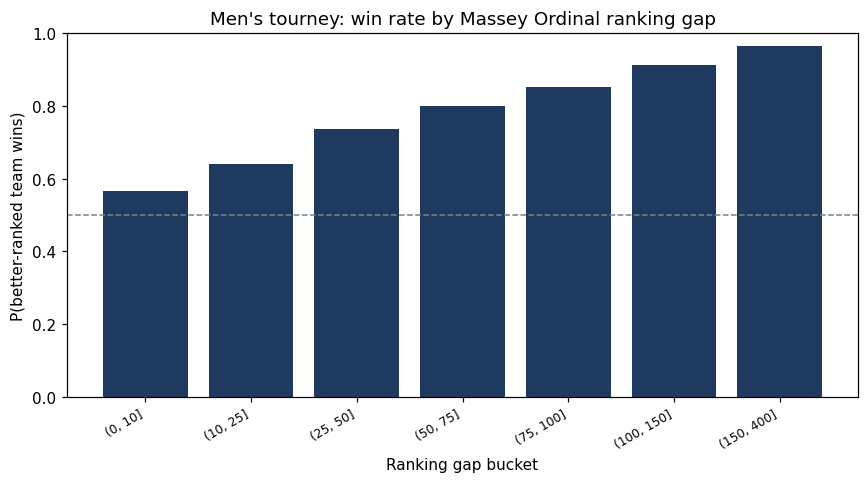

In [5]:
last_day = ordinals.groupby("Season")["RankingDayNum"].transform("max")
final_ordinals = ordinals[ordinals["RankingDayNum"] == last_day]
avg_rank = final_ordinals.groupby(["Season", "TeamID"])["OrdinalRank"].mean()

df = m_tourney.copy()
df["WRank"] = df.apply(lambda r: avg_rank.get((r["Season"], r["WTeamID"]), np.nan), axis=1)
df["LRank"] = df.apply(lambda r: avg_rank.get((r["Season"], r["LTeamID"]), np.nan), axis=1)
df = df.dropna(subset=["WRank", "LRank"])
df["BetterRankWon"] = df["WRank"] <= df["LRank"]
df["RankGap"] = (df["LRank"] - df["WRank"]).abs()

print(f"better-ranked team won {df['BetterRankWon'].mean():.1%} of {len(df)} games with ranking data")

fig, ax = plt.subplots(figsize=(8, 4.5))
bucket_edges = [0, 10, 25, 50, 75, 100, 150, 400]
df["RankGapBucket"] = pd.cut(df["RankGap"], bucket_edges)
rate = df.groupby("RankGapBucket", observed=True)["BetterRankWon"].agg(["mean", "count"])
ax.bar(range(len(rate)), rate["mean"], color="#1f3a5f")
ax.set_xticks(range(len(rate)))
ax.set_xticklabels([str(i) for i in rate.index], rotation=30, ha="right", fontsize=8)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_ylabel("P(better-ranked team wins)")
ax.set_xlabel("Ranking gap bucket")
ax.set_title("Men's tourney: win rate by Massey Ordinal ranking gap")
ax.set_ylim(0, 1)
fig.tight_layout()
plt.show()


## 5. Seed vs. ranking — same information, or different?

Follow-up to the seed-vs-ranking discussion: seed is a coarse (1-16), once-a-year, committee judgment; the Massey Ordinal is a continuous, repeatedly-recalculated, algorithmic one. If they mostly agree, including both as features is redundant. If they diverge meaningfully, the *disagreement itself* (a team seeded worse than its ranking suggests, or vice versa) could be a genuinely useful engineered feature — several researched winning solutions used something like a 'custom rating differential' alongside seed rather than seed alone.

correlation between seed and ordinal rank: 0.822 (n=1540 team-seasons)

Ranked much BETTER than their seed implied (committee arguably under-seeded them):
 Season TeamName  SeedNum  OrdinalRank
   2011  Utah St       12    19.211538
   2021  Colgate       14    40.096154
   2012  Belmont       14    44.637931
   2011  Belmont       13    35.020408
   2012      BYU       14    44.931034

Ranked much WORSE than their seed implied (committee arguably over-seeded them):
 Season      TeamName  SeedNum  OrdinalRank
   2023   F Dickinson       16   295.225806
   2025 St Francis PA       16   291.037037
   2026  Prairie View       16   291.000000
   2024        Wagner       16   289.912281
   2018    NC Central       16   289.306452


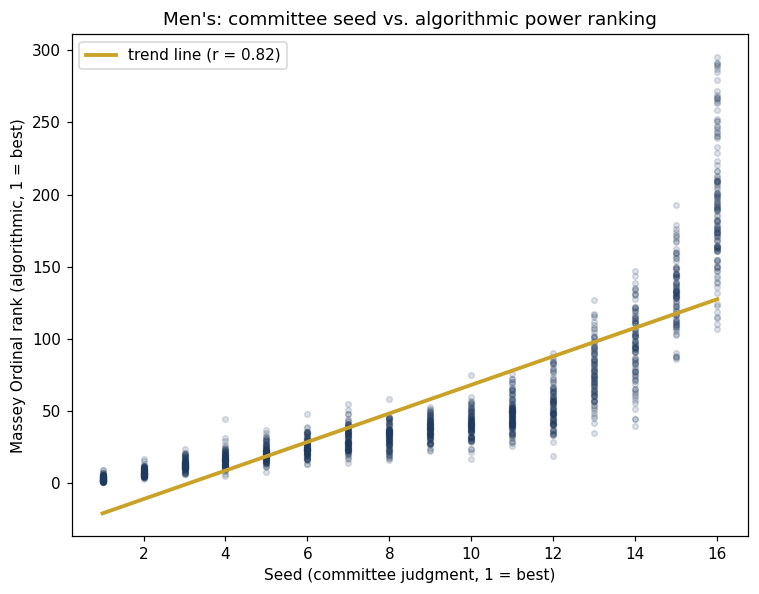

In [6]:
seed_rank = m_seeds.merge(m_teams[["TeamID", "TeamName"]], on="TeamID", how="left")
seed_rank["OrdinalRank"] = seed_rank.apply(lambda r: avg_rank.get((r["Season"], r["TeamID"]), np.nan), axis=1)
seed_rank = seed_rank.dropna(subset=["OrdinalRank"])

corr = seed_rank["SeedNum"].corr(seed_rank["OrdinalRank"])
print(f"correlation between seed and ordinal rank: {corr:.3f} (n={len(seed_rank)} team-seasons)")

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(seed_rank["SeedNum"], seed_rank["OrdinalRank"], alpha=0.15, s=14, color="#1f3a5f")
z = np.polyfit(seed_rank["SeedNum"], seed_rank["OrdinalRank"], 1)
xs = np.array([1, 16])
ax.plot(xs, np.polyval(z, xs), color="#c9a227", linewidth=2.5, label=f"trend line (r = {corr:.2f})")
ax.set_xlabel("Seed (committee judgment, 1 = best)")
ax.set_ylabel("Massey Ordinal rank (algorithmic, 1 = best)")
ax.set_title("Men's: committee seed vs. algorithmic power ranking")
ax.legend()
fig.tight_layout()
plt.show()

# teams furthest off the trend line = biggest seed/ranking disagreements
seed_rank["ExpectedRank"] = np.polyval(z, seed_rank["SeedNum"])
seed_rank["Residual"] = seed_rank["OrdinalRank"] - seed_rank["ExpectedRank"]

print("\nRanked much BETTER than their seed implied (committee arguably under-seeded them):")
print(seed_rank.nsmallest(5, "Residual")[["Season", "TeamName", "SeedNum", "OrdinalRank"]].to_string(index=False))

print("\nRanked much WORSE than their seed implied (committee arguably over-seeded them):")
print(seed_rank.nlargest(5, "Residual")[["Season", "TeamName", "SeedNum", "OrdinalRank"]].to_string(index=False))


## 6. Sanity check — does the lower TeamID just win more often?

The training file orients every row as Team1 (lower TeamID) vs. Team2 (higher TeamID), matching the submission format, with Label = 1 if Team1 won. TeamIDs were assigned once, not based on team strength — but before trusting that framing for training, it's worth directly checking there isn't some hidden historical artifact (e.g. older/more established programs happening to have lower IDs) that makes the label quietly imbalanced. If this came out far from 50%, that would be a real problem worth fixing before model training, not after.

men's tourney:          lower TeamID won 51.2% of 2,585 games
women's tourney:        lower TeamID won 51.7% of 1,717 games
men's regular season:   lower TeamID won 48.9% of 198,577 games
women's regular season: lower TeamID won 50.2% of 142,507 games


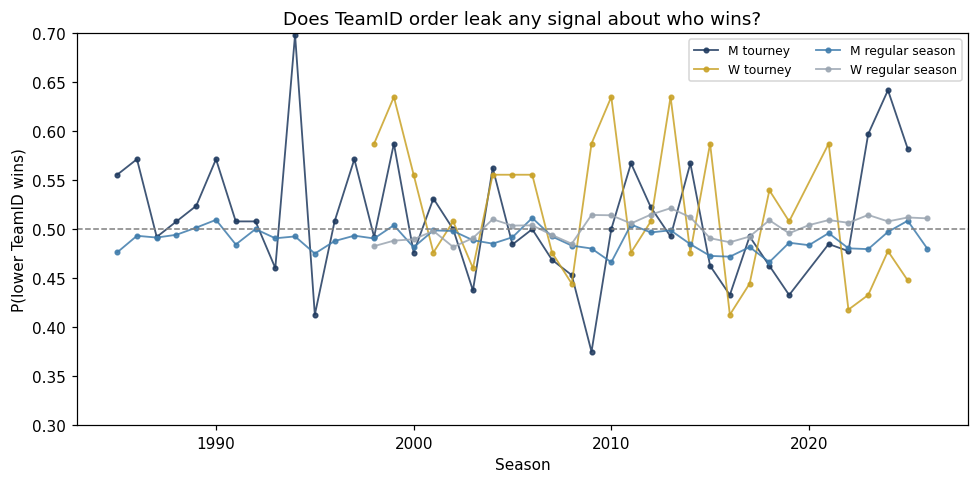

In [7]:
def lowid_winrate(results):
    df = results.copy()
    df["LowID"] = df[["WTeamID", "LTeamID"]].min(axis=1)
    df["LowIDWon"] = df["WTeamID"] == df["LowID"]
    return df

m_t_low = lowid_winrate(m_tourney)
w_t_low = lowid_winrate(w_tourney)
m_r_low = lowid_winrate(m_reg)
w_r_low = lowid_winrate(w_reg)

print(f"men's tourney:          lower TeamID won {m_t_low['LowIDWon'].mean():.1%} of {len(m_t_low):,} games")
print(f"women's tourney:        lower TeamID won {w_t_low['LowIDWon'].mean():.1%} of {len(w_t_low):,} games")
print(f"men's regular season:   lower TeamID won {m_r_low['LowIDWon'].mean():.1%} of {len(m_r_low):,} games")
print(f"women's regular season: lower TeamID won {w_r_low['LowIDWon'].mean():.1%} of {len(w_r_low):,} games")

fig, ax = plt.subplots(figsize=(9, 4.5))
for df, label, color in [
    (m_t_low, "M tourney", "#1f3a5f"), (w_t_low, "W tourney", "#c9a227"),
    (m_r_low, "M regular season", "#3f7cac"), (w_r_low, "W regular season", "#9aa5b1"),
]:
    rate = df.groupby("Season")["LowIDWon"].mean()
    ax.plot(rate.index, rate.values, marker="o", markersize=3, linewidth=1.2, label=label, color=color, alpha=0.85)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_ylabel("P(lower TeamID wins)")
ax.set_xlabel("Season")
ax.set_ylim(0.3, 0.7)
ax.set_title("Does TeamID order leak any signal about who wins?")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()


## Summary of visual findings

**1. Seed gap vs. win rate.** The better-seeded team wins ~72% (men's) / ~78% (women's) of
non-tied-seed tournament games, climbing roughly with seed gap but with a real dip around a
5-6 gap (classic mid-major upset territory). Confirms seed differential belongs in the feature
set as a solid baseline signal, but the noise at moderate gaps means it can't be the only one —
a seed-only model will systematically miss a predictable chunk of upsets.

**2. Regular season vs. tournament margins.** Winning-margin distributions are nearly identical
(median 10 points either way). Supports the Option C training-scope recommendation — building
features from regular-season data shouldn't introduce a systematic mismatch with tournament
conditions, at least not on this measure.

**3. Coverage timeline.** Visually confirms the 2020 COVID gap, the later start dates for
detailed box-score stats (2003 men's, 2010 women's), and that no file contains 2026 results.
Direct guardrail for the minimal model: any season-based validation split must skip 2020, and
detailed-stats features need a fallback for seasons before 2003/2010.

**4. Ranking gap vs. outcome.** Win rate climbs cleanly from 57% to 97% as the Massey Ordinal
ranking gap widens, with none of the seed chart's noisy dip. Ranking differential may be a
stronger standalone predictor than seed differential — worth testing head-to-head once the
minimal model exists.

**5. Seed vs. ranking.** Correlated (r = 0.82) but genuinely different signals, not redundant.
Teams the algorithm rates far better than their seed (Utah St. 2011, Belmont 2011/2012) look
like classic under-seeded sleepers; the biggest "over-seeded" cases are all 16-seeds hitting the
seed scale's floor rather than real committee misjudgments. Worth engineering a seed-vs-rank gap
as its own feature, not just feeding in both raw numbers.

**6. TeamID order sanity check.** Lower TeamID wins close to 50% in every split (48.9%-51.7%);
the wider swings in the tournament-only lines are small-sample noise (~32-67 games/season), not
bias. Clears the Team1(low)/Team2(high) framing for the minimal model — no correction needed
before training.
